In [1]:
import sympy as sp
from sympy import symbols, sqrt, Matrix, init_printing, Symbol, latex, zeros, Rational

init_printing()

#D1Q4 model

def Hn(x):
    # polynomial H_4(x)
    H = 16*x**4 - 48*x**2 + 12
    return H

def Hpn(x):
    # Derivative of H_4(x)
    H = 64*x**3 - 96*x
    return H

def weights(n, x):
    wj = (2**(n+1) * sp.factorial(n) * sp.sqrt(sp.pi)) / Hpn(x)**2
    return wj

x = sp.symbols('x')

n = 4

# Numerical roots of H_4(x)
x_points = sp.nroots(Hn(x))

# Sort roots from negative to positive
x_points = sorted(x_points, key=lambda val: float(sp.re(val)))

weights_n_x = [weights(n, val) for val in x_points]

# Normalized weights: W_j = w_j / sqrt(pi)
weights_normalized_n_x = [sp.simplify(val / sp.sqrt(sp.pi)) for val in weights_n_x]

display(sp.Eq(sp.symbols('H_4(x)'), Hn(x), evaluate=False))
display(sp.Eq(sp.symbols("H'_4(x)"), Hpn(x), evaluate=False))

print("Numerical roots:")
for val in x_points:
    display(sp.Eq(sp.symbols('x_j'), val, evaluate=False))

print("Raw Gauss-Hermite weights:")
for val in weights_n_x:
    display(sp.Eq(sp.symbols('w'), val, evaluate=False))

print("Normalized weights W = w/sqrt(pi):")
for val in weights_normalized_n_x:
    display(sp.Eq(sp.symbols('W'), val, evaluate=False))


Numerical roots:


Raw Gauss-Hermite weights:


Normalized weights W = w/sqrt(pi):


D2Q16 normalized weights:


Check sum of D2Q16 weights:


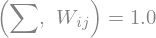

In [2]:
# D2Q16 = D1Q4 x D1Q4

weights_D2Q16 = []

for i in range(4):
    for j in range(4):
        Wij = sp.simplify(weights_normalized_n_x[i] * weights_normalized_n_x[j])
        weights_D2Q16.append(Wij)

print("D2Q16 normalized weights:")
for val in weights_D2Q16:
    display(sp.Eq(sp.symbols('W_{ij}'), val, evaluate=False))

print("Check sum of D2Q16 weights:")
display(sp.Eq(sp.symbols(r'\sum W_{ij}'), sum(weights_D2Q16), evaluate=False))

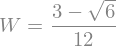

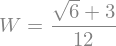

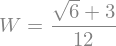

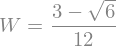

In [ ]:
#simplified symbolic expressions 

weights_symbolic = [
    sp.together(sp.nsimplify(val, [sp.sqrt(6)]))
    for val in weights_normalized_n_x
]

for val in weights_symbolic:
    display(sp.Eq(sp.symbols('W'), val, evaluate=False))